<a href="https://colab.research.google.com/github/Naganarthanan/RiceGuard-DL/blob/shanu/Model_2_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = '/content/drive/MyDrive/rice_disease_split'

for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(files), "files")

/content/drive/MyDrive/rice_disease_split -> 1 files
/content/drive/MyDrive/rice_disease_split/test -> 0 files
/content/drive/MyDrive/rice_disease_split/test/Leaf_scald -> 95 files
/content/drive/MyDrive/rice_disease_split/test/Bacterial_Leaf_Blight -> 96 files
/content/drive/MyDrive/rice_disease_split/test/Healthy_Rice_Leaf -> 99 files
/content/drive/MyDrive/rice_disease_split/test/Leaf_Blast -> 94 files
/content/drive/MyDrive/rice_disease_split/test/Sheath_Blight -> 95 files
/content/drive/MyDrive/rice_disease_split/test/Brown_Spot -> 97 files
/content/drive/MyDrive/rice_disease_split/val -> 0 files
/content/drive/MyDrive/rice_disease_split/val/Leaf_scald -> 94 files
/content/drive/MyDrive/rice_disease_split/val/Healthy_Rice_Leaf -> 97 files
/content/drive/MyDrive/rice_disease_split/val/Bacterial_Leaf_Blight -> 95 files
/content/drive/MyDrive/rice_disease_split/val/Leaf_Blast -> 92 files
/content/drive/MyDrive/rice_disease_split/val/Brown_Spot -> 95 files
/content/drive/MyDrive/rice_

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/rice_disease_split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/rice_disease_split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/rice_disease_split/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # test data-க்கு shuffle வேண்டாம், evaluation-க்கு order தேவை
)

Found 2655 images belonging to 6 classes.
Found 567 images belonging to 6 classes.
Found 576 images belonging to 6 classes.


In [5]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# base layers freeze பண்றது
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [7]:
num_classes = train_data.num_classes
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1535s 19s/step - accuracy: 0.3733 - loss: 1.5329 - val_accuracy: 0.5873 - val_loss: 1.2920
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 413ms/step - accuracy: 0.4727 - loss: 1.3045 - val_accuracy: 0.6279 - val_loss: 1.0763
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 415ms/step - accuracy: 0.5360 - loss: 1.1333 - val_accuracy: 0.7125 - val_loss: 0.9573
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 415ms/step - accuracy: 0.5815 - loss: 1.0299 - val_accuracy: 0.7372 - val_loss: 0.8668
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 34s 412ms/step - accuracy: 0.6316 - loss: 0.9268 - val_accuracy: 0.7231 - val_loss: 0.7944
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 34s 406ms/step - accuracy: 0.6241 - loss: 0.8930 - val_accuracy: 0.7390 - val_loss: 0.8290
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 420ms/step - accuracy: 0.6599 - loss: 0.8361 - val_accuracy: 0.7619 - val_loss: 0.7055
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 34s 403ms/step - accuracy: 0.6870 - loss: 0.7556 - val_accu

In [11]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 300ms/step - accuracy: 0.7882 - loss: 0.6161
Test Accuracy: 78.82%


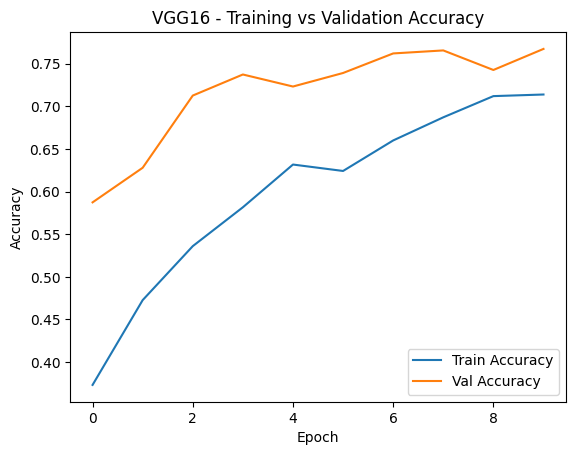

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('VGG16 - Training vs Validation Accuracy')
plt.show()